# Business Problem Understanding
This project analyzes client investment and revenue patterns for a mutual fund advisory to support data-driven client acquisition, retention, and revenue optimization strategies.


In [ ]:
import pandas as pd

In [ ]:
amc_aum_path = '/content/AMC_AUM.xlsx'
client_master_path = '/content/client_master_a.xlsx'
time_series_path = '/content/time series.xlsx'
type_wise_path = '/content/type wise aum.xlsx'

# Data Overview
The dataset includes client profile and investment-level data from a mutual fund advisory. It contains demographic attributes (age, income, marital status, earning status, responsibilities), behavioral indicators (risk appetite, network degree), and investment metrics such as AUM, SIP contributions, and redemptions.

The analysis focuses on understanding client value, identifying revenue-driving customers, and evaluating investment behavior patterns to support business strategy decisions.


In [ ]:
client_master = pd.read_excel(client_master_path, sheet_name="Sheet1")
type_wise_aum = pd.read_excel(type_wise_path, sheet_name="Sheet1")
amc_aum = pd.read_excel(amc_aum_path, sheet_name="sheet1")
time_aum = pd.read_excel(time_series_path, sheet_name="time_aum")
year_new_sip = pd.read_excel(time_series_path, sheet_name="year_new_sip")
time_total_clients = pd.read_excel(time_series_path, sheet_name="time_total_clients")
date_redemption = pd.read_excel(time_series_path, sheet_name="date_redemption")

# Exploratory Data Analysis
This section explores client demographics, investment behavior, and distribution patterns to understand underlying trends and identify key drivers of client value and revenue contribution.


In [ ]:
client_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Client Name         266 non-null    object 
 1   Monthly income      266 non-null    object 
 2   Gender              266 non-null    object 
 3   Earning individual  266 non-null    object 
 4   Responsibility      266 non-null    object 
 5   Mode of income      266 non-null    object 
 6   Network degree      266 non-null    object 
 7   Marriage status     266 non-null    object 
 8   Risk apetite        266 non-null    object 
 9   Location            266 non-null    object 
 10  Age                 266 non-null    float64
 11  SIP                 266 non-null    int64  
 12  AUM                 266 non-null    float64
 13  Redemption amount   266 non-null    float64
 14  Redemption count    266 non-null    int64  
 15  Months              266 non-null    float64
dtypes: float

In [ ]:
type_wise_aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Asset Type  4 non-null      object
 1   AUM         4 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 196.0+ bytes


In [ ]:
amc_aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AMC     25 non-null     object 
 1   AUM     25 non-null     float64
dtypes: float64(1), object(1)
memory usage: 532.0+ bytes


In [ ]:
time_aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    32 non-null     datetime64[ns]
 1   AUM     32 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 644.0 bytes


In [ ]:
year_new_sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Year     9 non-null      int64
 1   New SIP  9 non-null      int64
dtypes: int64(2)
memory usage: 276.0 bytes


In [ ]:
time_total_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     8 non-null      datetime64[ns]
 1   Clients  8 non-null      int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 260.0 bytes


In [ ]:
date_redemption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    360 non-null    datetime64[ns]
 1   Amount  360 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


In [ ]:
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
client_master.describe()

,Age,SIP,AUM,Redemption amount,Redemption count,Months
count,266.00,266.00,266.00,266.00,266.00,266.00
mean,41.54,6219.92,349701.53,102601.26,2.42,47.31
std,12.57,8695.89,586508.69,296906.16,8.60,29.45
min,10.00,0.00,0.00,0.00,0.00,0.00
25%,32.00,1125.00,51057.34,0.00,0.00,21.00
50%,42.00,3750.00,141565.73,0.00,0.00,48.94
75%,49.00,7375.00,342115.18,65174.50,2.00,73.00
max,77.00,50000.00,5085883.42,2941983.73,121.00,92.00


In [ ]:
type_wise_aum.describe()

,AUM
count,4.00
mean,23033336.25
std,33095378.18
min,182.00
25%,2117215.25
50%,10454062.00
75%,31370183.00
max,71225039.00


In [ ]:
amc_aum.describe()

,AUM
count,25.00
mean,7254254.38
std,18813519.51
min,846.13
25%,131543.42
50%,552805.28
75%,2463653.33
max,90678179.77


In [ ]:
year_new_sip['New SIP'].describe()

,New SIP
count,9.00
mean,366386.33
std,235051.68
min,95500.00
25%,194500.00
50%,320997.00
75%,525000.00
max,728485.00


In [ ]:
time_total_clients['Clients'].describe()

,Clients
count,8.00
mean,153.88
std,66.59
min,49.00
25%,118.25
50%,152.00
75%,196.00
max,255.00


In [ ]:
columns_to_check = ["SIP"]

# Function to remove outliers using IQR
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)  # 25th percentile
        Q3 = df[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1                # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR  # Lower bound
        upper_bound = Q3 + 1.5 * IQR  # Upper bound

        # Remove rows where "SIP" or "AUM" values are outside the bounds
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

# Apply outlier removal to "SIP" and "AUM" only
client_masterr = remove_outliers_iqr(client_master, columns_to_check)

# Print summary after removing outliers
client_masterr.describe()

,Age,SIP,AUM,Redemption amount,Redemption count,Months
count,247.00,247.00,247.00,247.00,247.00,247.00
mean,41.88,4277.33,278847.90,86850.67,2.36,48.00
std,12.40,4138.48,416470.85,230562.56,8.71,29.73
min,10.00,0.00,0.00,0.00,0.00,0.00
25%,32.50,1000.00,45712.40,0.00,0.00,21.00
50%,42.00,3000.00,130768.30,0.00,0.00,48.94
75%,49.00,5750.00,305505.20,65019.92,2.00,76.00
max,77.00,16000.00,3149295.61,2480228.40,121.00,92.00


In [ ]:
client_masterr.shape

(247, 16)

In [ ]:
# Define bins for SIP
sip_bins = [0, 3000, 6000, 9000, 12000, 15000, 18000, 21000, 24000, 50000]
client_master["SIP Group"] = pd.cut(client_master["SIP"], bins=sip_bins, include_lowest=True)

# Define bins for AUM
aum_bins = [0, 200000, 400000, 600000, 800000, 1000000, 1200000, 1400000, 1600000, 1800000, 2000000, 6000000]
client_master["AUM Group"] = pd.cut(client_master["AUM"], bins=aum_bins, include_lowest=True)

# Define bins for Redemption Amount
redemption_bins = [0, 1, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 1000000]
client_master["Redemption Group"] = pd.cut(client_master["Redemption amount"], bins=redemption_bins, include_lowest=True)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np

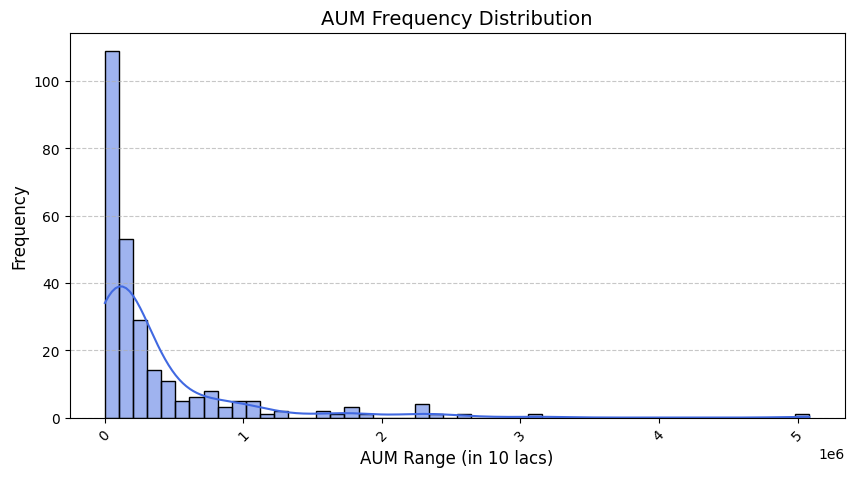

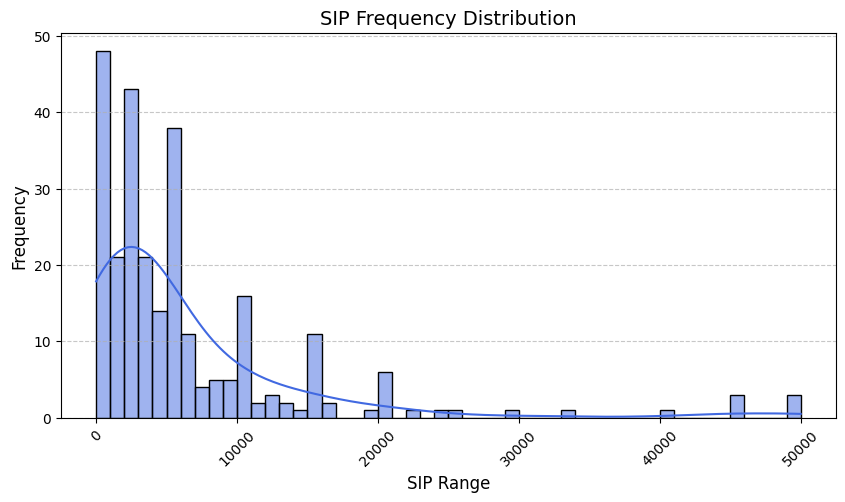

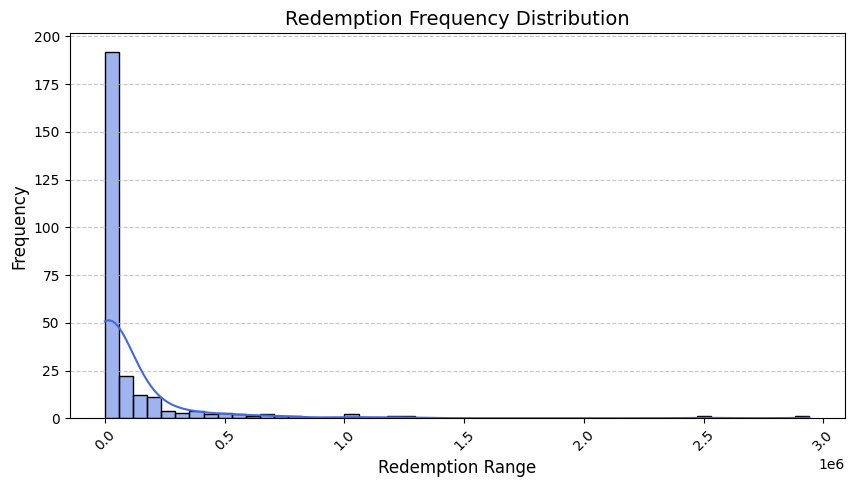

In [ ]:
def plot_frequency_distribution(data, column, title, xlabel, bins=50):
    plt.figure(figsize=(10, 5))

    # Histogram with KDE
    sns.histplot(data[column], bins=bins, kde=True, color="royalblue", edgecolor="black")

    # Titles and labels
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    # Custom x-ticks based on bin edges
    plt.xticks(rotation=45)

    # Grid for better readability
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show plot
    plt.show()

# Example usage
plot_frequency_distribution(client_master, "AUM", "AUM Frequency Distribution", "AUM Range (in 10 lacs)")
plot_frequency_distribution(client_master, "SIP", "SIP Frequency Distribution", "SIP Range")
plot_frequency_distribution(client_master, "Redemption amount", "Redemption Frequency Distribution", "Redemption Range")

In [ ]:
sip_non_zero = client_master[client_master["SIP"] != 0]["SIP"]  # Filter out zero values
sip_non_zero.describe()

,SIP
count,218.000000
mean,7589.449541
std,9050.041560
min,1000.000000
25%,2000.000000
50%,5000.000000
75%,10000.000000
max,50000.000000


#Pareto Analysis

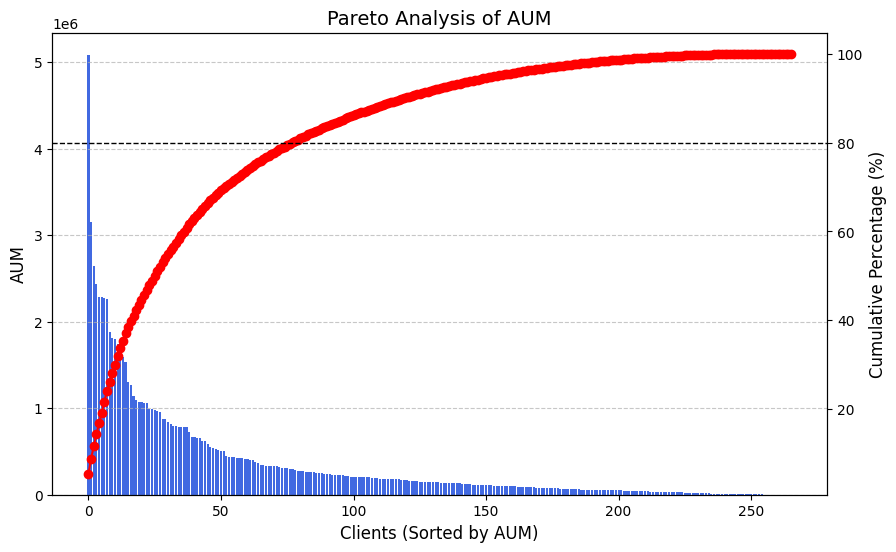

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data (replace 'your_file.csv' with actual filename)
df = pd.read_excel("/content/client_master_a.xlsx", sheet_name="Sheet1")

# Sort AUM in descending order
df = df.sort_values(by="AUM", ascending=False)

# Calculate cumulative sum and percentage
df["Cumulative AUM"] = df["AUM"].cumsum()
df["Cumulative Percentage"] = 100 * df["Cumulative AUM"] / df["AUM"].sum()

# Plot Pareto Chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for AUM
ax1.bar(df.index, df["AUM"], color="royalblue", label="AUM")
ax1.set_ylabel("AUM", fontsize=12)
ax1.set_xlabel("Clients (Sorted by AUM)", fontsize=12)

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(df.index, df["Cumulative Percentage"], color="red", marker="o", label="Cumulative %")
ax2.set_ylabel("Cumulative Percentage (%)", fontsize=12)
ax2.axhline(80, color="black", linestyle="dashed", linewidth=1)  # 80% threshold line

# Show grid and labels
plt.title("Pareto Analysis of AUM", fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
cagr = ((90912388.63/26234288.8)**(1/5))-1
cagr

0.2821851854579569